# Checking yields after cuts

In [1]:
%run load-rds-final-2012-23903000-rs.ipynb

Welcome to JupyROOT 6.28/00


Loaded rdf with 305828 enries


In [2]:
def mygroupby(d, groupbycols):
    g = d.groupby(groupbycols).size().reset_index(name='count').sort_values([ 'count'], ascending=False).reset_index(drop=True)
    g["Percentage"] = g.apply(lambda row: 100 * row["count"]/d.shape[0], axis=1)
    g["cumulative %"] = g["Percentage"].cumsum(axis = 0)
    return g

In [3]:
def categ_groupby(df, groupbycol, threshold):
    """ Group the dataframe df by column groupbycol, grouping together entries rows with count < threshold """
    g = pd.DataFrame(df.groupby(groupbycol).count()["category"]).rename(columns={"category":"count"})
    g["Category"] = g.apply(lambda row: row.name if row["count"] > threshold else "others", axis=1)
    g2 = g.groupby("Category").sum()
    g2 = g2.sort_values([ 'count'], ascending=False)
    total = g2.sum()["count"]
    g2["Percentage"] = g2.apply(lambda row: 100 * row["count"]/total, axis=1)
    g2["cumulative %"] = g2["Percentage"].cumsum(axis = 0)
    return g, g2

In [4]:
rdf.Count().GetValue()

305828

In [5]:
import categories4 as f
rdf_initial = rdf
rdf = f.add_categories_and_filter(rdf_initial,  apply_BDT_Iso_cut=True, apply_PIDK_cut=True)

In [6]:
rdf.Count().GetValue()

242740

In [7]:
base_columns = [ "eventIndex", "category", "simplified", "B_M", "B_Y_SEP", "Xc_signal_Ypis_displaced_fromBs_fromTau", "fromY_from_B_vertex", "BDT_Iso", "q2_2"]
load_columns = [
    "Y_0_40_nc_mult",
    "Y_0_20_cc_mult",
    "Y_0_20_cc_PZ",
    "Y_0_30_nc_PZ",
    "Y_0_40_nc_PZ",
    "min_m2pi",
    "max_m2pi",
    "missing_mass_2",
    "B_BPVVDR",
    "B_M",
    "B_correctedMass",
#     "log(abs(PBsn))",
#     "log(abs(PBv/B_P))",
#     "log(abs(PBvn/B_P))",
#     "log(abs((PBsn-PBvn)/PBvn))",
#     "log(sqrt(abs(mDs2vn)))",
    "mN2v",
#    "log(Y_PE)",
    "BDT_Iso",
    "B_pT_Bdir",
    "Y_BPVVDR",
    "missing_pY_mass",
    "Y_correctedMass",
    'PBsn',
    'PBv', 'PBvn', 'B_P', 'mDs2vn', 'Y_PE'
]
train_columns = [
    "Y_0_40_nc_mult",
    "Y_0_20_cc_mult",
    "Y_0_20_cc_PZ",
    "Y_0_30_nc_PZ",
    "Y_0_40_nc_PZ",
    "min_m2pi",
    "max_m2pi",
    "missing_mass_2",
    "B_BPVVDR",
    "B_M",
    "B_correctedMass",
    "log(abs(PBsn))",
    "log(abs(PBv/B_P))",
    "log(abs(PBvn/B_P))",
    "log(abs((PBsn-PBvn)/PBvn))",
    "log(sqrt(abs(mDs2vn)))",
    "mN2v",
    "log(Y_PE)",
    "BDT_Iso",
    "B_pT_Bdir",
    "Y_BPVVDR",
    "missing_pY_mass",
    "Y_correctedMass",
]

columns = base_columns +  load_columns
df = pd.DataFrame(rdf.Cache(columns).AsNumpy())


In [8]:
df['simplified_key'] = df.apply(lambda row: f.pretty_categories_map[row["simplified"]], axis=1)
df['key'] = df.apply(lambda row: f.categories_map[row["category"]], axis=1)
df['signal'] = (df['simplified_key'] == 'Signal')
dfbm = df.query("B_M < 5000")

In [31]:
_, categ_before_bysep_cut = categ_groupby(df, 'simplified_key', 100)
categ_before_bysep_cut

,count,Percentage,cumulative %
Category,,,
Double Charm,211882,87.287633,87.287633
Bad Xc,21459,8.840323,96.127956
Signal,3567,1.469474,97.597429
Normalization like,2729,1.124248,98.721678
Combinatorial,1764,0.726703,99.448381
Tau from charm,1113,0.458515,99.906896
Other displaced,178,0.073329,99.980226
others,48,0.019774,100.000000


In [32]:
_, categ_after_bysep_cut = categ_groupby(dfbm, 'simplified_key', 100)
categ_after_bysep_cut

,count,Percentage,cumulative %
Category,,,
Double Charm,204311,87.645747,87.645747
Bad Xc,20449,8.772253,96.418000
Signal,3562,1.528034,97.946034
Normalization like,2034,0.872549,98.818584
Combinatorial,1433,0.614731,99.433315
Tau from charm,1110,0.476170,99.909485
Other displaced,163,0.069924,99.979409
others,48,0.020591,100.000000


In [33]:
categ_after_bysep_cut["before"] = categ_after_bysep_cut.apply(lambda row: categ_before_bysep_cut.loc[row.name]['count'], axis=1)
categ_after_bysep_cut["cut efficiency"] = categ_after_bysep_cut["count"] / categ_after_bysep_cut["before"]

In [34]:
categ_after_bysep_cut

,count,Percentage,cumulative %,before,cut efficiency
Category,,,,,
Double Charm,204311,87.645747,87.645747,211882.0,0.964268
Bad Xc,20449,8.772253,96.418000,21459.0,0.952934
Signal,3562,1.528034,97.946034,3567.0,0.998598
Normalization like,2034,0.872549,98.818584,2729.0,0.745328
Combinatorial,1433,0.614731,99.433315,1764.0,0.812358
Tau from charm,1110,0.476170,99.909485,1113.0,0.997305
Other displaced,163,0.069924,99.979409,178.0,0.915730
others,48,0.020591,100.000000,48.0,1.000000


THIS INCLUDES THE CUT q2_2 > 0 BY DEFAULT

In [35]:
print(categ_after_bysep_cut[['count', 'Percentage', 'cut efficiency']].to_latex(float_format="%.3f" ))

\begin{tabular}{lrrr}
\toprule
{} &   count &  Percentage &  cut efficiency \\
Category           &         &             &                 \\
\midrule
Double Charm       &  204311 &      87.646 &           0.964 \\
Bad Xc             &   20449 &       8.772 &           0.953 \\
Signal             &    3562 &       1.528 &           0.999 \\
Normalization like &    2034 &       0.873 &           0.745 \\
Combinatorial      &    1433 &       0.615 &           0.812 \\
Tau from charm     &    1110 &       0.476 &           0.997 \\
Other displaced    &     163 &       0.070 &           0.916 \\
others             &      48 &       0.021 &           1.000 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_277646/1900856644.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(categ_after_bysep_cut[['count', 'Percentage', 'cut efficiency']].to_latex(float_format="%.3f" ))


In [36]:
import joblib
bdtdblcharm = joblib.load("../../train_bdt/bdtdblcharm_150_3_0.04.pkl")
def add_cols_for_bdt(tmpdf):
    df = tmpdf.copy()
    df["log(abs(PBsn))"] = np.log(np.abs(df["PBsn"]))
    df["log(abs(PBv/B_P))"] = np.log(np.abs(df["PBv"] / df["B_P"]))
    df["log(abs(PBvn/B_P))"] = np.log(np.abs(df["PBvn"] / df["B_P"]))
    df["log(abs((PBsn-PBvn)/PBvn))"] = np.log(np.abs((df["PBsn"] - df["PBvn"]) / df["PBvn"]))
    df["log(sqrt(abs(mDs2vn)))"] = np.log(np.sqrt(np.abs(df["mDs2vn"])))
    df["log(Y_PE)"] = np.log(df["Y_PE"]) 
    df["diff_m2pi"] = df["max_m2pi"] - df["min_m2pi"]
    return df
dfbm2 = add_cols_for_bdt(dfbm)

In [37]:
dfbm2['bdt_dc'] = bdtdblcharm.predict_proba(dfbm2[train_columns])[:,1]

In [38]:
dfbm2.to_hdf('data_with_bdt_dc.h5', key='df', mode='w')

/tmp/ipykernel_277646/2196017620.py:1: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['Xc_signal_Ypis_displaced_fromBs_fromTau', 'fromY_from_B_vertex',
       'simplified_key', 'key'],
      dtype='object')]

  dfbm2.to_hdf('data_with_bdt_dc.h5', key='df', mode='w')


## Evaluating datasets after cuts

In [39]:
df_cut1 = dfbm2.query("bdt_dc >0.75")

In [40]:
def compare_categories(before, after):
    _, categs_before = categ_groupby(before, 'simplified_key', 100)
    _, categs_after = categ_groupby(after, 'simplified_key', 100)
    categs_after["before"] = categs_after.apply(lambda row: categs_before.loc[row.name]['count'], axis=1)
    categs_after["cut efficiency"] = categs_after["count"] / categs_after["before"]
    categs_after["remaining"] = categs_after["count"] / categs_after["before"]
    
    return categs_after

categs_cut1 = compare_categories(dfbm2, df_cut1)

categs_cut1

,count,Percentage,cumulative %,before,cut efficiency,remaining
Category,,,,,,
Double Charm,10127,76.102803,76.102803,204311.0,0.049567,0.049567
Signal,1429,10.738709,86.841512,3562.0,0.401179,0.401179
Bad Xc,1337,10.047344,96.888855,20449.0,0.065382,0.065382
Normalization like,212,1.593146,98.482002,2034.0,0.104228,0.104228
Tau from charm,157,1.179830,99.661832,1110.0,0.141441,0.141441
others,45,0.338168,100.000000,48.0,0.937500,0.937500


In [41]:
print(categs_cut1[['count', 'Percentage', 'cut efficiency']].to_latex(float_format="%.3f" ))

\begin{tabular}{lrrr}
\toprule
{} &  count &  Percentage &  cut efficiency \\
Category           &        &             &                 \\
\midrule
Double Charm       &  10127 &      76.103 &           0.050 \\
Signal             &   1429 &      10.739 &           0.401 \\
Bad Xc             &   1337 &      10.047 &           0.065 \\
Normalization like &    212 &       1.593 &           0.104 \\
Tau from charm     &    157 &       1.180 &           0.141 \\
others             &     45 &       0.338 &           0.938 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_277646/413638731.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(categs_cut1[['count', 'Percentage', 'cut efficiency']].to_latex(float_format="%.3f" ))


In [42]:
categs_cut2 = compare_categories(dfbm2, dfbm2.query("bdt_dc >0.35"))
categs_cut2

,count,Percentage,cumulative %,before,cut efficiency,remaining
Category,,,,,,
Double Charm,77343,85.123267,85.123267,204311.0,0.378555,0.378555
Bad Xc,8352,9.192164,94.315430,20449.0,0.408431,0.408431
Signal,3005,3.307286,97.622716,3562.0,0.843627,0.843627
Normalization like,931,1.024653,98.647370,2034.0,0.457719,0.457719
Tau from charm,794,0.873872,99.521241,1110.0,0.715315,0.715315
Combinatorial,370,0.407220,99.928461,1433.0,0.258200,0.258200
others,65,0.071539,100.000000,48.0,1.354167,1.354167


In [43]:
print(categs_cut2[['count', 'Percentage', 'cut efficiency']].to_latex(float_format="%.3f" ))

\begin{tabular}{lrrr}
\toprule
{} &  count &  Percentage &  cut efficiency \\
Category           &        &             &                 \\
\midrule
Double Charm       &  77343 &      85.123 &           0.379 \\
Bad Xc             &   8352 &       9.192 &           0.408 \\
Signal             &   3005 &       3.307 &           0.844 \\
Normalization like &    931 &       1.025 &           0.458 \\
Tau from charm     &    794 &       0.874 &           0.715 \\
Combinatorial      &    370 &       0.407 &           0.258 \\
others             &     65 &       0.072 &           1.354 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_277646/3301345270.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(categs_cut2[['count', 'Percentage', 'cut efficiency']].to_latex(float_format="%.3f" ))


In [44]:
categs_cut3 = compare_categories(dfbm2, dfbm2.query("bdt_dc >0.5"))
categs_cut3

,count,Percentage,cumulative %,before,cut efficiency,remaining
Category,,,,,,
Double Charm,44742,83.061672,83.061672,204311.0,0.218990,0.218990
Bad Xc,5151,9.562618,92.624290,20449.0,0.251895,0.251895
Signal,2592,4.811941,97.436231,3562.0,0.727681,0.727681
Normalization like,610,1.132440,98.568670,2034.0,0.299902,0.299902
Tau from charm,555,1.030335,99.599005,1110.0,0.500000,0.500000
Combinatorial,176,0.326737,99.925742,1433.0,0.122819,0.122819
others,40,0.074258,100.000000,48.0,0.833333,0.833333


In [45]:
print(categs_cut3[['count', 'Percentage', 'cut efficiency']].to_latex(float_format="%.3f" ))

\begin{tabular}{lrrr}
\toprule
{} &  count &  Percentage &  cut efficiency \\
Category           &        &             &                 \\
\midrule
Double Charm       &  44742 &      83.062 &           0.219 \\
Bad Xc             &   5151 &       9.563 &           0.252 \\
Signal             &   2592 &       4.812 &           0.728 \\
Normalization like &    610 &       1.132 &           0.300 \\
Tau from charm     &    555 &       1.030 &           0.500 \\
Combinatorial      &    176 &       0.327 &           0.123 \\
others             &     40 &       0.074 &           0.833 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_277646/1098370202.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(categs_cut3[['count', 'Percentage', 'cut efficiency']].to_latex(float_format="%.3f" ))


In [46]:
def get_cut_result(df):
    cuts = np.arange(0.0, 1.0, 0.005)
    nb_total = len(df)
    nb_sig = len(df[df['signal']==1])
    nb_bkg = len(df[df['signal']==0])
    print(f"Total: {nb_total}, sig:{nb_sig}, bkg:{nb_bkg}, ratio: {nb_bkg/nb_sig:.2f}")
    results = []
    for c in cuts:
        dftmp = df.query(f"bdt_dc > {c}")
        nbs = len(dftmp.query("signal == 1"))
        nbb = len(dftmp.query("signal == 0"))
        results.append((c, nbs, nbb))
    dfresult = pd.DataFrame(results, columns=["cut", "sig", "bkg"])
    dfresult["bkg/sig"] = dfresult["bkg"] / dfresult["sig"]
    dfresult["fom1"] = dfresult["sig"] / np.sqrt(dfresult["sig"] + dfresult["bkg"])
    dfresult["sig_eff"] = dfresult["sig"] / nb_sig
    dfresult["bkg_eff"] = dfresult["bkg"] / nb_bkg
    return dfresult

dfresult = get_cut_result(dfbm2.query("eventIndex==1"))

Total: 116543, sig:1772, bkg:114771, ratio: 64.77


In [47]:
dfresult


,cut,sig,bkg,bkg/sig,fom1,sig_eff,bkg_eff
0,0.000,1772,114771,64.769187,5.190637,1.0,1.000000
1,0.005,1772,114771,64.769187,5.190637,1.0,1.000000
2,0.010,1772,114770,64.768623,5.190659,1.0,0.999991
3,0.015,1772,114767,64.766930,5.190726,1.0,0.999965
4,0.020,1772,114690,64.723476,5.192441,1.0,0.999294
...,...,...,...,...,...,...,...
195,0.975,0,0,NaN,NaN,0.0,0.000000
196,0.980,0,0,NaN,NaN,0.0,0.000000
197,0.985,0,0,NaN,NaN,0.0,0.000000
198,0.990,0,0,NaN,NaN,0.0,0.000000


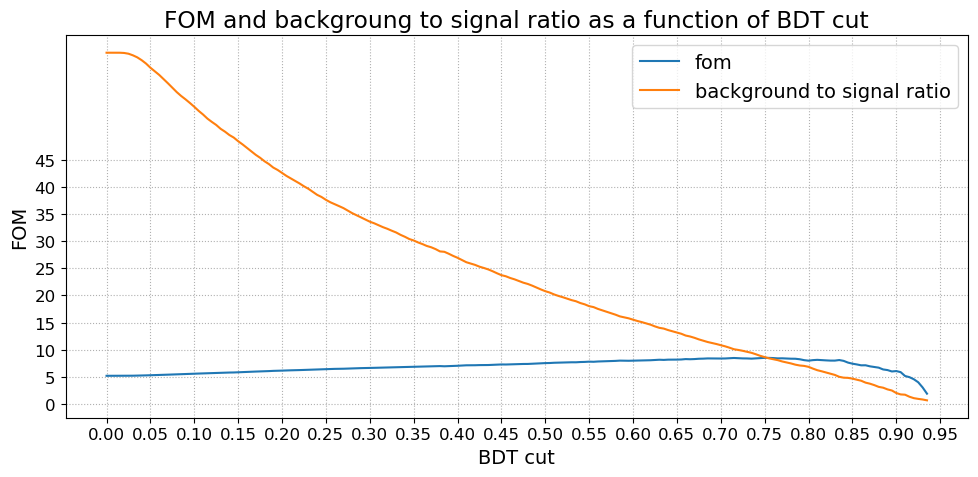

In [48]:
plt.rcParams["figure.figsize"] = (10,5)
plt.rcParams.update({'font.size': 14})
plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12) 
plt.plot(dfresult["cut"], dfresult["fom1"], label="fom");
plt.plot(dfresult["cut"], dfresult["bkg/sig"], label="background to signal ratio");
# ax = plt.gca()
# ax.set_ylim([0, 100])
plt.xticks(np.arange(0, 1, 0.05))
plt.yticks(np.arange(0, 50, 1))
plt.grid( linestyle=":", )
plt.xticks(np.arange(0, 1, 0.05))
plt.yticks(np.arange(0, 50, 5))
plt.xlabel("BDT cut")
plt.ylabel("FOM")
plt.legend()
plt.title("FOM and backgroung to signal ratio as a function of BDT cut");
plt.tight_layout()
plt.savefig("dblcharmbdt_FOM.png")

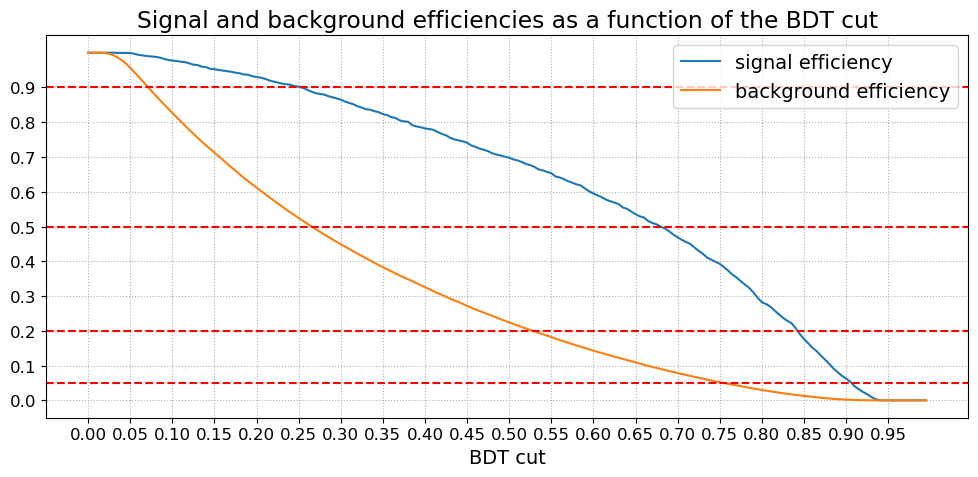

In [49]:
plt.rcParams["figure.figsize"] = (10,5)
plt.rcParams.update({'font.size': 14})
plt.plot(dfresult["cut"], dfresult["sig_eff"], label="signal efficiency");
plt.plot(dfresult["cut"], dfresult["bkg_eff"], label="background efficiency");
plt.xlabel("BDT cut")
plt.legend()
plt.rc('xtick', labelsize=10) 
plt.rc('ytick', labelsize=10) 
plt.axhline(y = 0.9, color = 'r', linestyle = '--')
plt.axhline(y = 0.5, color = 'r', linestyle = '--')
plt.axhline(y = 0.2, color = 'r', linestyle = '--')
plt.axhline(y = 0.05, color = 'r', linestyle = '--')
plt.xticks(np.arange(0, 1, 0.05))
plt.yticks(np.arange(0, 1, 0.1))
plt.grid( linestyle=":", )
plt.title("Signal and background efficiencies as a function of the BDT cut");
plt.tight_layout()
plt.savefig("dblcharmbdt_eff.png");

In [50]:
dfresult.query("abs(cut -0.75) < 0.03")

,cut,sig,bkg,bkg/sig,fom1,sig_eff,bkg_eff
145,0.725,762,7468,9.800525,8.399531,0.430023,0.065069
146,0.730,747,7179,9.610442,8.390611,0.421558,0.062551
147,0.735,728,6864,9.428571,8.355131,0.410835,0.059806
148,0.740,717,6570,9.163180,8.399332,0.404628,0.057244
149,0.745,706,6264,8.872521,8.456454,0.398420,0.054578
150,0.750,696,6008,8.632184,8.500456,0.392777,0.052348
151,0.755,679,5710,8.409426,8.494803,0.383183,0.049751
152,0.760,661,5442,8.232980,8.461157,0.373025,0.047416
153,0.765,641,5177,8.076443,8.403712,0.361738,0.045107
154,0.770,626,4905,7.835463,8.417294,0.353273,0.042737


In [51]:
dfresult.query("abs(cut -0.5) < 0.01")

,cut,sig,bkg,bkg/sig,fom1,sig_eff,bkg_eff
99,0.495,1242,26227,21.116747,7.493767,0.700903,0.228516
100,0.500,1237,25721,20.793048,7.534004,0.698081,0.224107
101,0.505,1228,25227,20.543160,7.549957,0.693002,0.219803


In [52]:
dfresult.query("abs(cut -0.35) < 0.01")

,cut,sig,bkg,bkg/sig,fom1,sig_eff,bkg_eff
68,0.340,1474,45441,30.828358,6.805211,0.831828,0.395928
69,0.345,1469,44678,30.413887,6.838330,0.829007,0.389280
70,0.350,1459,43986,30.148047,6.844035,0.823363,0.383250
71,0.355,1454,43307,29.784732,6.872496,0.820542,0.377334
